
================ DATASET ================

        MONTH  AGE  PARLE-G  GOOD DAY  HIDE & SEEK  MILK BIKIS  MARIE GOLD
0     JANUARY   10      120        95           80         110         100
1    FEBRUARY   15      135       105           85         115         108
2       MARCH   20      150       120           95         125         115
3       APRIL   25      140       110           90         120         112
4         MAY   30      165       130          105         135         125
5        JUNE   35      155       125          100         130         120
6        JULY   40      175       140          115         145         135
7      AUGUST   45      180       145          120         150         140
8   SEPTEMBER   50      160       130          110         140         128
9     OCTOBER   55      190       155          125         160         150
10   NOVEMBER   60      200       165          135         170         160
11   DECEMBER   65      220       180          150      

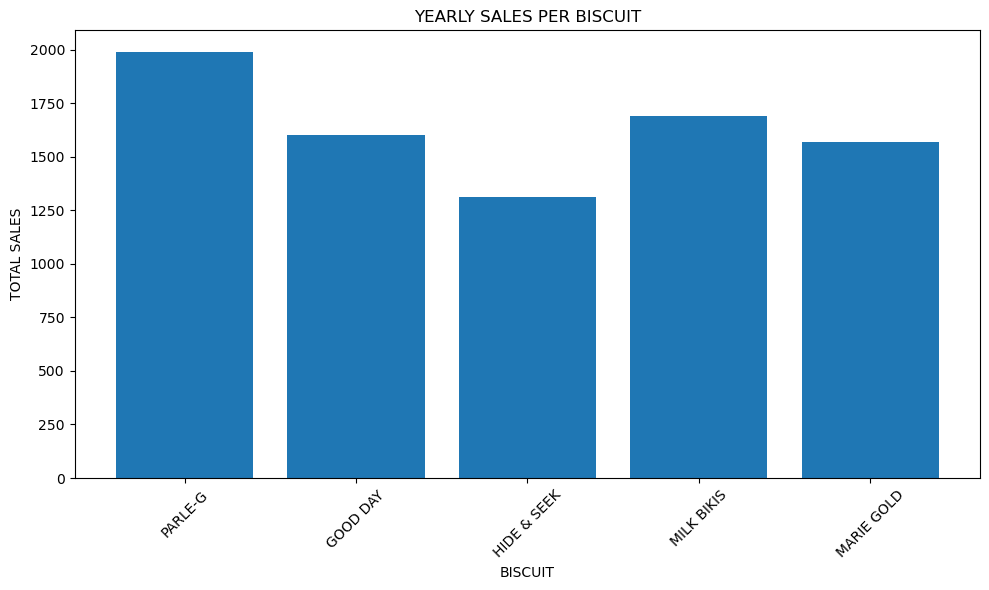

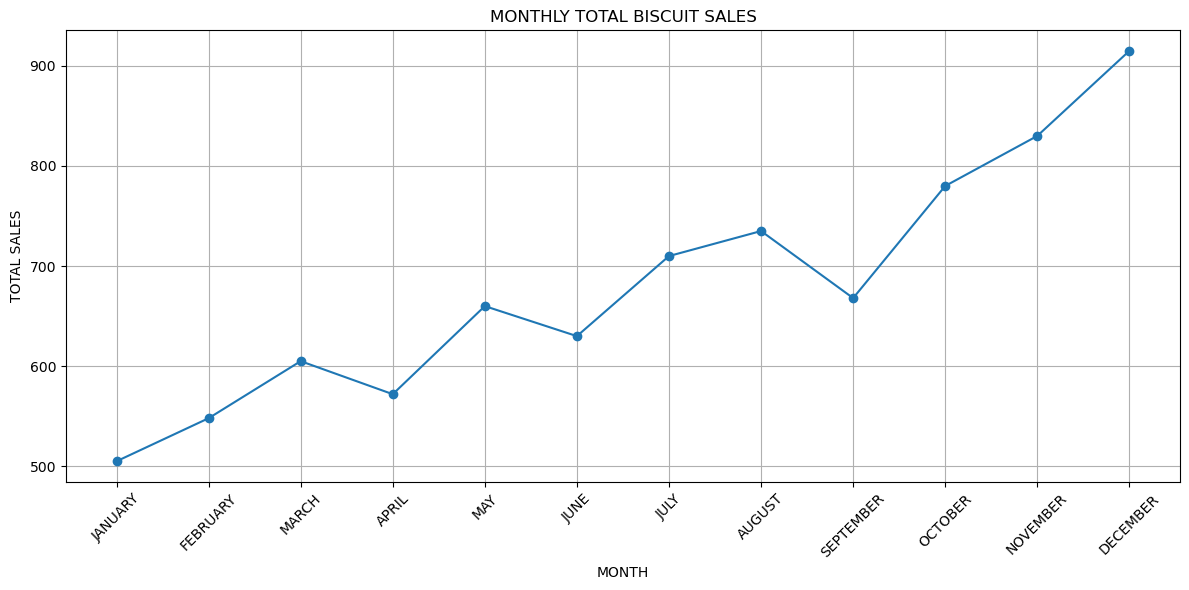

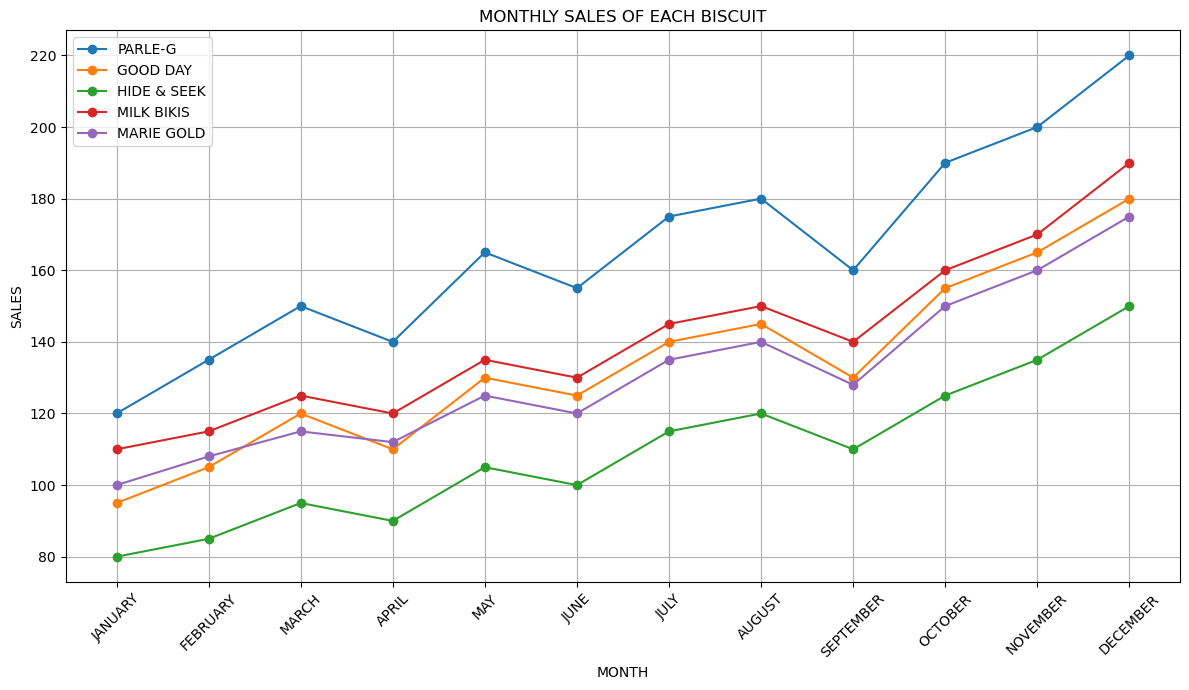

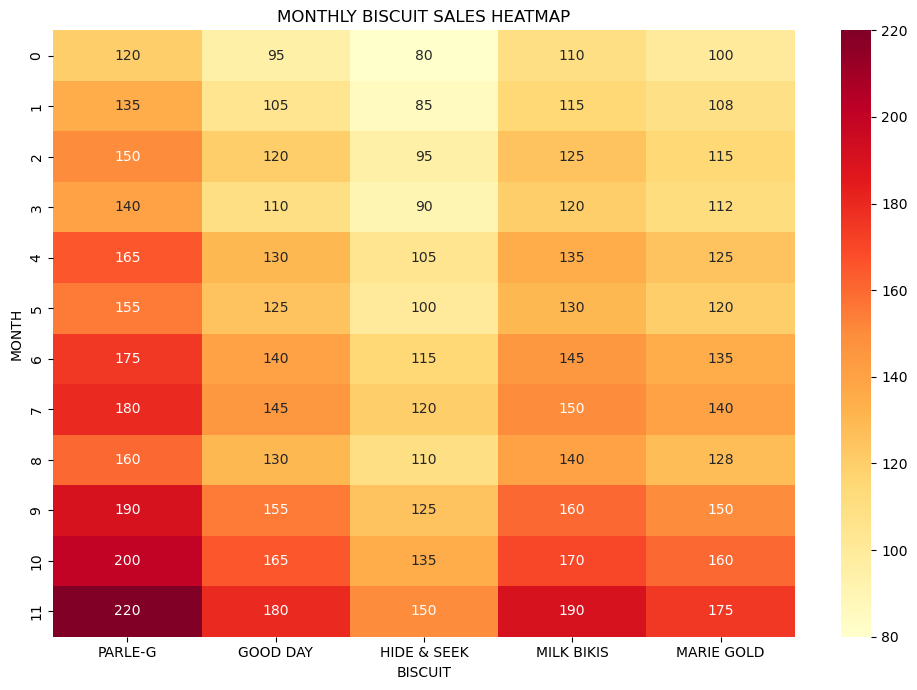

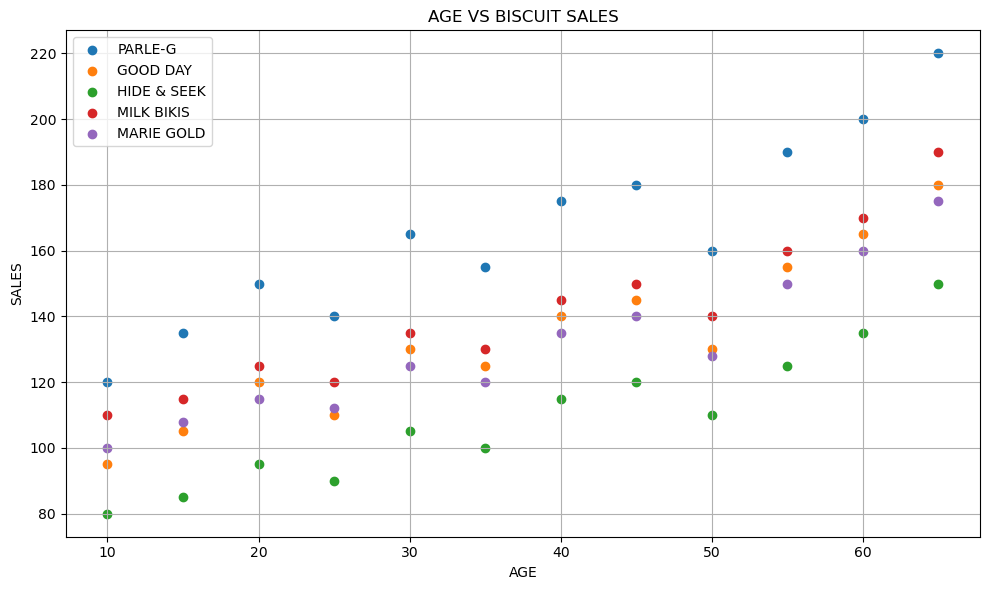

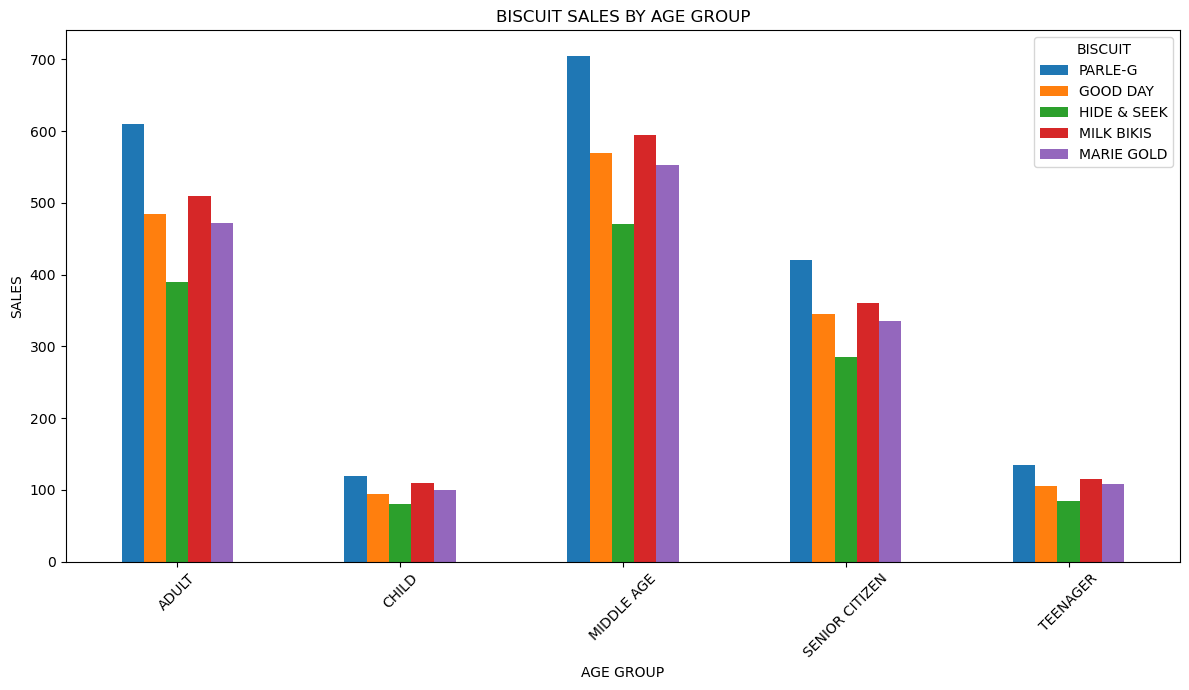

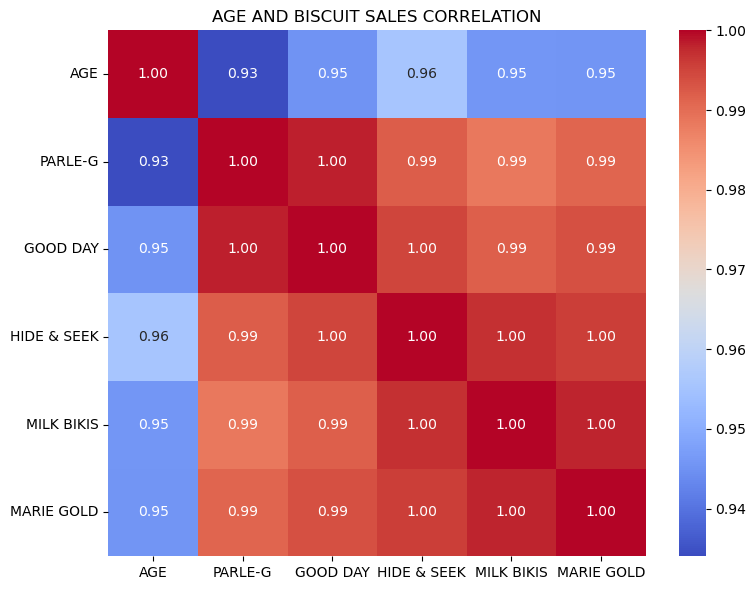


              FINAL INSIGHTS

1. HIGHEST SELLING BISCUIT : PARLE-G
2. LOWEST SELLING BISCUIT  : HIDE & SEEK
3. HIGHEST SALES MONTH     : DECEMBER
4. LOWEST SALES MONTH      : JANUARY

5. YEARLY SALES:
PARLE-G        1990
GOOD DAY       1600
HIDE & SEEK    1310
MILK BIKIS     1690
MARIE GOLD     1568
dtype: int64

6. AGE GROUP WISE SALES:
                PARLE-G  GOOD DAY  HIDE & SEEK  MILK BIKIS  MARIE GOLD
AGE GROUP                                                             
ADULT               610       485          390         510         472
CHILD               120        95           80         110         100
MIDDLE AGE          705       570          470         595         553
SENIOR CITIZEN      420       345          285         360         335
TEENAGER            135       105           85         115         108


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# READ CSV FILE
df = pd.read_csv("biscuit_sales.csv")

print("\n================ DATASET ================\n")
print(df)


# BASIC EDA


print("\n================ FIRST 5 ROWS ================\n")
print(df.head())

print("\n================ LAST 5 ROWS ================\n")
print(df.tail())

print("\n================ INFORMATION ================\n")
df.info()

print("\n================ SHAPE ================\n")
print("ROWS    :", df.shape[0])
print("COLUMNS :", df.shape[1])

print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())

print("\n================ DUPLICATES ================\n")
print(df.duplicated().sum())

print("\n================ STATISTICS ================\n")
print(df.describe())


# BISCUIT COLUMNS

biscuits = [
    "PARLE-G",
    "GOOD DAY",
    "HIDE & SEEK",
    "MILK BIKIS",
    "MARIE GOLD"
]


# 1. WHICH BISCUIT HAS THE HIGHEST SALES?

total_sales = df[biscuits].sum()

print("\n================ TOTAL YEARLY SALES ================\n")
print(total_sales)

highest_biscuit = total_sales.idxmax()
highest_sales = total_sales.max()

lowest_biscuit = total_sales.idxmin()
lowest_sales = total_sales.min()

print("\nHIGHEST SELLING BISCUIT")
print("BISCUIT :", highest_biscuit)
print("SALES   :", highest_sales)

print("\nLOWEST SELLING BISCUIT")
print("BISCUIT :", lowest_biscuit)
print("SALES   :", lowest_sales)


# 2. MONTHLY TOTAL SALES

df["TOTAL SALES"] = df[biscuits].sum(axis=1)

print("\n================ MONTHLY TOTAL SALES ================\n")
print(df[["MONTH", "TOTAL SALES"]])


# 3. WHICH MONTH HAS HIGHEST AND LOWEST SALES?

highest_month_index = df["TOTAL SALES"].idxmax()
lowest_month_index = df["TOTAL SALES"].idxmin()

print("\n================ MONTH ANALYSIS ================\n")

print("HIGHEST SALES MONTH")
print("MONTH :", df.loc[highest_month_index, "MONTH"])
print("SALES :", df.loc[highest_month_index, "TOTAL SALES"])

print("\nLOWEST SALES MONTH")
print("MONTH :", df.loc[lowest_month_index, "MONTH"])
print("SALES :", df.loc[lowest_month_index, "TOTAL SALES"])


# 4. WHICH BISCUIT IS HIGH / LOW EACH MONTH?

print("\n================ MONTHLY HIGH / LOW BISCUIT ================\n")

for index, row in df.iterrows():

    month = row["MONTH"]

    highest = row[biscuits].idxmax()
    highest_value = row[biscuits].max()

    lowest = row[biscuits].idxmin()
    lowest_value = row[biscuits].min()

    print("\nMONTH :", month)

    print(
        "HIGH :",
        highest,
        "->",
        highest_value
    )

    print(
        "LOW  :",
        lowest,
        "->",
        lowest_value
    )


# 5. AGE GROUP ANALYSIS

def age_group(age):

    if age <= 12:
        return "CHILD"
    elif age <= 19:
        return "TEENAGER"
    elif age <= 35:
        return "ADULT"
    elif age <= 59:
        return "MIDDLE AGE"
    else:
        return "SENIOR CITIZEN"


df["AGE GROUP"] = df["AGE"].apply(age_group)

print("\n================ AGE GROUP ================\n")
print(df[["AGE", "AGE GROUP"]])


# 6. WHICH AGE PERSON BUYS WHICH BISCUIT?

print("\n================ AGE WISE BISCUIT SALES ================\n")

for index, row in df.iterrows():

    age = row["AGE"]

    biscuit = row[biscuits].idxmax()

    sales = row[biscuits].max()

    print(
        "AGE :", age,
        "| AGE GROUP :", row["AGE GROUP"],
        "| BISCUIT :", biscuit,
        "| SALES :", sales
    )


# 7. AGE GROUP VS BISCUIT

age_sales = df.groupby("AGE GROUP")[biscuits].sum()

print("\n================ AGE GROUP BISCUIT SALES ================\n")
print(age_sales)


# 8. MOST POPULAR BISCUIT FOR EACH AGE GROUP

print("\n================ POPULAR BISCUIT BY AGE GROUP ================\n")

for group in age_sales.index:

    popular_biscuit = age_sales.loc[group].idxmax()

    popular_sales = age_sales.loc[group].max()

    print(
        group,
        "->",
        popular_biscuit,
        "->",
        popular_sales
    )


# 9. YEARLY SALES PER BISCUIT

print("\n================ YEARLY SALES PER BISCUIT ================\n")

for biscuit in biscuits:

    print(
        biscuit,
        " : ",
        df[biscuit].sum()
    )


# VISUALIZATION


# GRAPH 1 - YEARLY SALES PER BISCUIT

plt.figure(figsize=(10, 6))

plt.bar(
    total_sales.index,
    total_sales.values
)

plt.title("YEARLY SALES PER BISCUIT")
plt.xlabel("BISCUIT")
plt.ylabel("TOTAL SALES")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# GRAPH 2 - MONTHLY TOTAL SALES

plt.figure(figsize=(12, 6))

plt.plot(
    df["MONTH"],
    df["TOTAL SALES"],
    marker="o"
)

plt.title("MONTHLY TOTAL BISCUIT SALES")
plt.xlabel("MONTH")
plt.ylabel("TOTAL SALES")

plt.xticks(rotation=45)

plt.grid()

plt.tight_layout()
plt.show()


# GRAPH 3 - EACH BISCUIT MONTHLY SALES

plt.figure(figsize=(12, 7))

for biscuit in biscuits:

    plt.plot(
        df["MONTH"],
        df[biscuit],
        marker="o",
        label=biscuit
    )

plt.title("MONTHLY SALES OF EACH BISCUIT")
plt.xlabel("MONTH")
plt.ylabel("SALES")

plt.xticks(rotation=45)

plt.legend()

plt.grid()

plt.tight_layout()
plt.show()


# GRAPH 4 - HEATMAP

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[biscuits],
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title("MONTHLY BISCUIT SALES HEATMAP")

plt.xlabel("BISCUIT")
plt.ylabel("MONTH")

plt.tight_layout()
plt.show()


# GRAPH 5 - AGE VS SALES

plt.figure(figsize=(10, 6))

for biscuit in biscuits:

    plt.scatter(
        df["AGE"],
        df[biscuit],
        label=biscuit
    )

plt.title("AGE VS BISCUIT SALES")

plt.xlabel("AGE")
plt.ylabel("SALES")

plt.legend()

plt.grid()

plt.tight_layout()
plt.show()


# GRAPH 6 - AGE GROUP SALES

age_sales.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("BISCUIT SALES BY AGE GROUP")

plt.xlabel("AGE GROUP")
plt.ylabel("SALES")

plt.xticks(rotation=45)

plt.legend(title="BISCUIT")

plt.tight_layout()
plt.show()


# GRAPH 7 - CORRELATION

plt.figure(figsize=(8, 6))

corr = df[["AGE"] + biscuits].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("AGE AND BISCUIT SALES CORRELATION")

plt.tight_layout()
plt.show()


# FINAL OUTPUT

print("\n==============================================")
print("              FINAL INSIGHTS")
print("==============================================")

print("\n1. HIGHEST SELLING BISCUIT :", highest_biscuit)

print("2. LOWEST SELLING BISCUIT  :", lowest_biscuit)

print("3. HIGHEST SALES MONTH     :",
      df.loc[highest_month_index, "MONTH"])

print("4. LOWEST SALES MONTH      :",
      df.loc[lowest_month_index, "MONTH"])

print("\n5. YEARLY SALES:")
print(total_sales)

print("\n6. AGE GROUP WISE SALES:")
print(age_sales)